In [2]:


from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution

import random
import os
import time
import numpy as np
import pylab as pl
from IPython import display

def simpleMD2(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    #initialize the temperature
    random.seed(701) #just making sure the MD failure is reproducible
    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    def write_plot_data():
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

    dyn.attach(write_plot_data, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()

    duration = (t1-t0)/60
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

    return time_fs, temperature, energies, duration

In [ ]:
init_conf = read('data/input1.xyz') #read a liquid config with periodic boundary conditions
init_conf.center()

# We can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=['learned_MACE/mace_learned_N4000_swa_compiled.model'], device='cuda', default_dtype="float32")

t_fs, temps, energies, time_md = simpleMD2(init_conf, temp=1500, calc=mace_calc, fname='moldyn/final_md_liquid_100ps.xyz', s=10, T=100000)


/usr/local/lib/python3.10/dist-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.d

Default dtype float32 does not match model dtype float64, converting models to float32.
removed 'moldyn/final_md_liquid_100ps.xyz'


/tmp/ipykernel_127588/2909524032.py:14: DeprecationWarning: Please use atoms.calc = calc
  init_conf.set_calculator(calc)


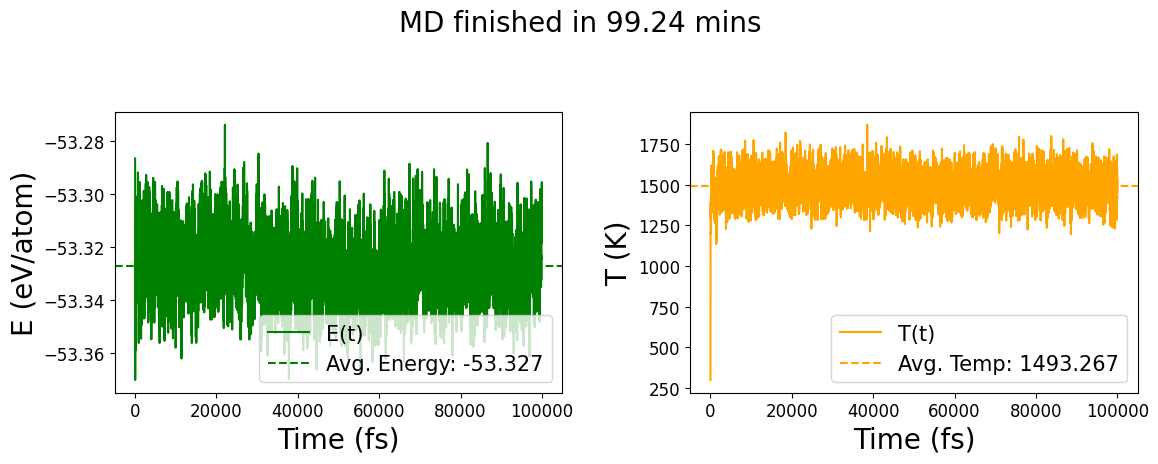

In [4]:
import matplotlib.pyplot as plt

fontsize = 20  # Set your desired base font size here

plt.rcParams.update({
    'font.size': fontsize,
    'axes.titlesize': fontsize + 2,
    'axes.labelsize': fontsize,
    'xtick.labelsize': fontsize * 0.6,
    'ytick.labelsize': fontsize * 0.6,
    'legend.fontsize': fontsize * 0.75,
    'figure.titlesize': fontsize
})

# Compute means rounded to 3 decimal places
mean_energy = round(np.mean(energies), 3)
mean_temp = round(np.mean(temps), 3)

# Create subplots: 1 row, 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Energy plot ---
axs[0].plot(t_fs, energies, color='green')
axs[0].axhline(y=mean_energy, color='green', linestyle='--')
axs[0].set_xlabel('Time (fs)')
axs[0].set_ylabel('E (eV/atom)')
axs[0].legend(['E(t)', f'Avg. Energy: {mean_energy}'], loc="lower right")

# --- Temperature plot ---
axs[1].plot(t_fs, temps, color='orange')
axs[1].axhline(y=mean_temp, color='orange', linestyle='--')
axs[1].set_xlabel('Time (fs)')
axs[1].set_ylabel('T (K)')
axs[1].legend(['T(t)', f'Avg. Temp: {mean_temp}'], loc='lower right')

# Adjust layout and show
fig.suptitle(f'MD finished in {round(time_md,2)} mins')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # leave space for the suptitle
plt.show()

In [5]:
import nglview as nv
traj = read('moldyn/final_md_liquid_10ps.xyz', ':')
nv.show_asetraj(traj)

NGLWidget(max_frame=1000)

In [6]:
from ase.io import read
import nglview as nv
import pandas as pd
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms

# --- Load a single frame from the XYZ file ---
single_frame = read('moldyn/final_md_liquid_10ps.xyz', index=0)

# --- Display the molecular structure using nglview ---
view = nv.show_ase(single_frame)
view.clear_representations()
view.add_representation('ball+stick')
view.add_representation('label', selection='all', labelType='atomname', labelColor='black', fontSize=1.0)
view.background = 'white'
view.center()
view  # Display the 3D viewer

# Extract atom data
atom_data = {
    'Index': range(len(single_frame)),
    'Name': [atom.symbol for atom in single_frame],  # Atom name or symbol
    'x': single_frame.positions[:, 0],
    'y': single_frame.positions[:, 1],
    'z': single_frame.positions[:, 2]
}

# Create DataFrame
df_atoms = pd.DataFrame(atom_data)

# Display the DataFrame
df_atoms  # In Jupyter, just df_atoms shows the full table


,Index,Name,x,y,z
0,0,C,10.30595,5.437325,1.26537
1,1,C,8.97200,6.147775,1.72833
2,2,O,9.30695,7.386915,2.25598
3,3,C,10.64578,7.370905,2.24128
4,4,O,11.30247,8.414425,2.57868
...,...,...,...,...,...
177,177,O,7.22837,5.146885,10.13997
178,178,H,5.66522,6.135355,9.72694
179,179,H,5.17960,4.610455,10.18018
180,180,H,5.55294,4.931105,12.69067


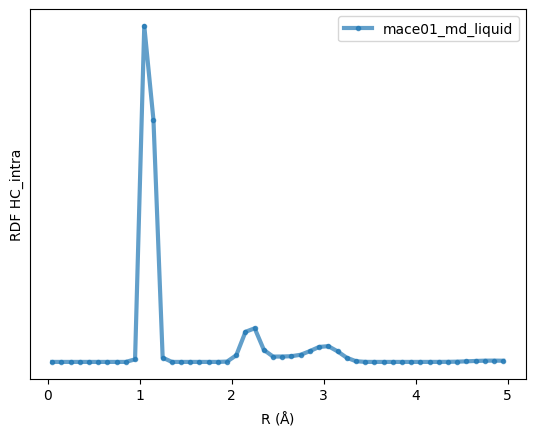

In [7]:
from aseMolec import anaAtoms as aa
from matplotlib import pyplot as plt

# tag = 'HH_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'
for tag in [ 'HC_intra',]:
    for f in ['final_md_liquid_10ps']:
        traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
        for at in traj:
            at.pbc = True #create a fake box for rdf compatibility
            at.cell = [100,100,100]
        rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
        plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)
    
    plt.legend();
    plt.yticks([]);
    plt.xlabel(r'R ($\rm \AA$)');
    plt.ylabel('RDF '+tag);
    plt.show()
